In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
model = joblib.load(
    "../models/best_model.pkl"
)

print(type(model))

C:\Users\Mihir\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: [16:15:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:402: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
C:\Users\Mihir\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: [16:15:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  setstate(state)
C:\Users\Mihir\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: [16:15:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  setstate(state)


<class 'xgboost.sklearn.XGBClassifier'>


In [3]:
df = pd.read_csv(
    "../data/processed/cleaned_dataset.csv"
)

In [4]:
X = df.drop(
    columns=[
        "diseases",
        "disease_encoded"
    ]
)

In [5]:
import re

def clean_cols(cols):

    cleaned = []

    for col in cols:

        col = str(col)

        col = re.sub(
            r"[^a-zA-Z0-9_]",
            "_",
            col
        )

        col = re.sub(
            r"_+",
            "_",
            col
        )

        cleaned.append(col)

    return cleaned

X.columns = clean_cols(X.columns)

In [6]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(20)

,feature,importance
326,sore_in_nose,0.197144
317,joint_swelling,0.157451
11,breathing_fast,0.106008
322,back_stiffness_or_tightness,0.086641
323,wrist_lump_or_mass,0.063653
301,shoulder_lump_or_mass,0.056760
284,hip_stiffness_or_tightness,0.052458
269,dry_or_flaky_scalp,0.028104
266,mass_or_swelling_around_the_anus,0.014610
250,eyelid_lesion_or_rash,0.010906


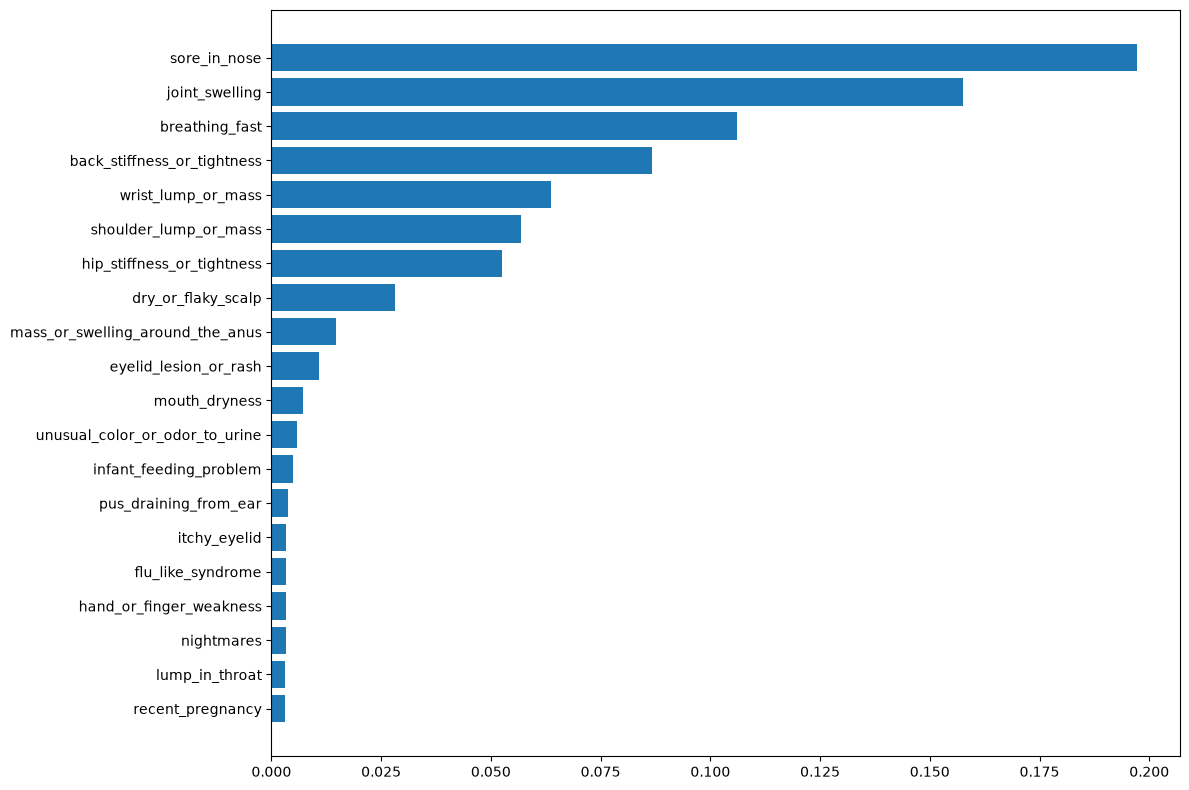

In [7]:
top20 = importance.head(20)

plt.figure(figsize=(12,8))

plt.barh(
    top20["feature"],
    top20["importance"]
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

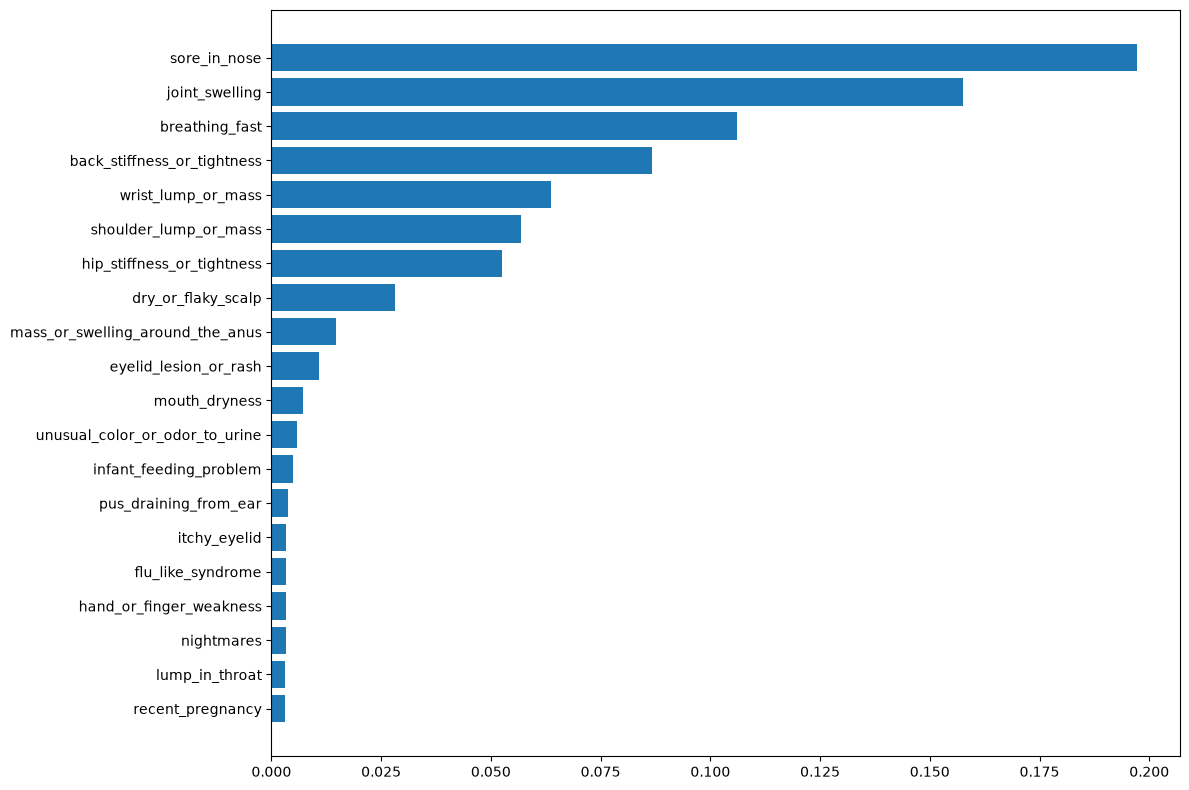

In [8]:
plt.figure(figsize=(12,8))

plt.barh(
    top20["feature"],
    top20["importance"]
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../reports/feature_importance.png",
    bbox_inches="tight"
)

In [9]:
importance.head(20)

,feature,importance
326,sore_in_nose,0.197144
317,joint_swelling,0.157451
11,breathing_fast,0.106008
322,back_stiffness_or_tightness,0.086641
323,wrist_lump_or_mass,0.063653
301,shoulder_lump_or_mass,0.056760
284,hip_stiffness_or_tightness,0.052458
269,dry_or_flaky_scalp,0.028104
266,mass_or_swelling_around_the_anus,0.014610
250,eyelid_lesion_or_rash,0.010906


In [10]:
importance.head(20).to_csv(
    "../reports/top_20_features.csv",
    index=False
)